# Butterworth-Van Dyke Filter experiments (Do not run: outdated methods)

This experiment uses the Butterworth Van Dyke filter, in an attempt to eliminate the lack of uniqueness of bridge frequency response for both the series and notch RLC filter. This last observation became a problem as soon as measurement noise was added to our simulations.

In [12]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager import Bridge

import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Initiation: load beam library, select beams for experiment and set parameters.
library_name = 'BVD6'
library = open_beam_library(library_name + '.json')
selection = ['A1', 'B1', 'C1']
lib = sublibrary(selection, library)

R_ref = 5e3 # Ohm
U_in = 10 # V

f_arr = np.logspace(2, 5, 1000)
w_arr = 2*np.pi*f_arr

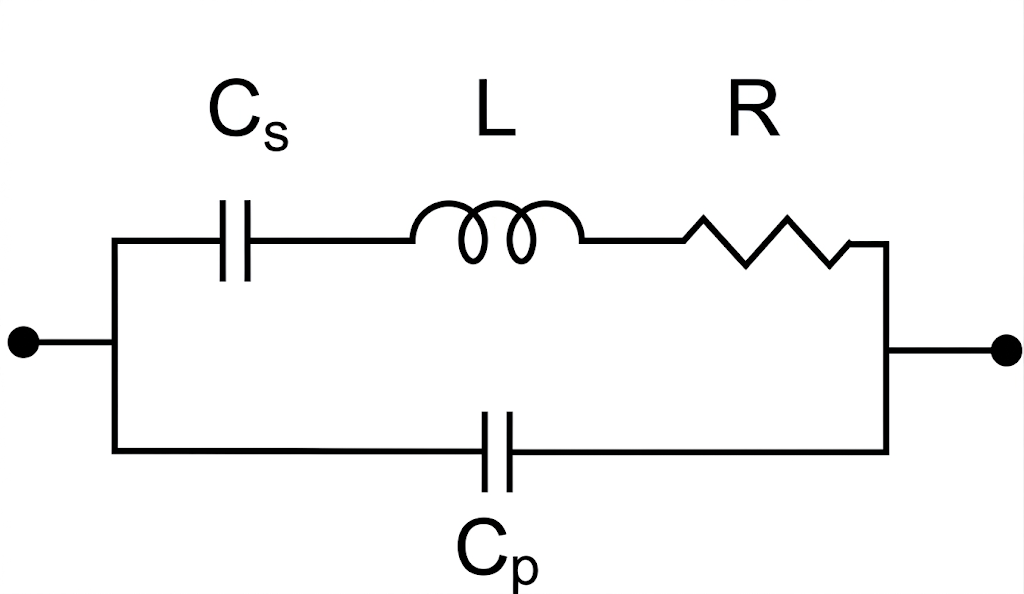

Above, we see the currently used filter. Right now, $C_p = 0.1C_s$ is used. First, we have a look at the new filter impedance, which should show both resonance and antiresonance:

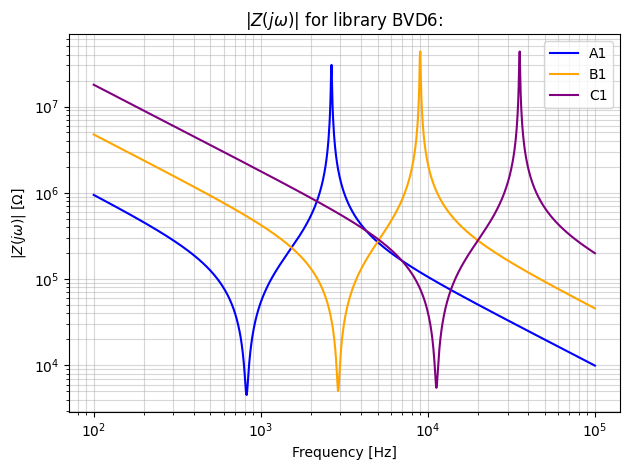

In [14]:
fig, ax = plt.subplots()
colors = ['blue', 'orange', 'purple']

for beam, color in zip(list(lib.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()

We see the characteristic BVD behaviour, located on different resonance frequencies for each beam. Now, we repeat our triangle simulation, with and without noise.


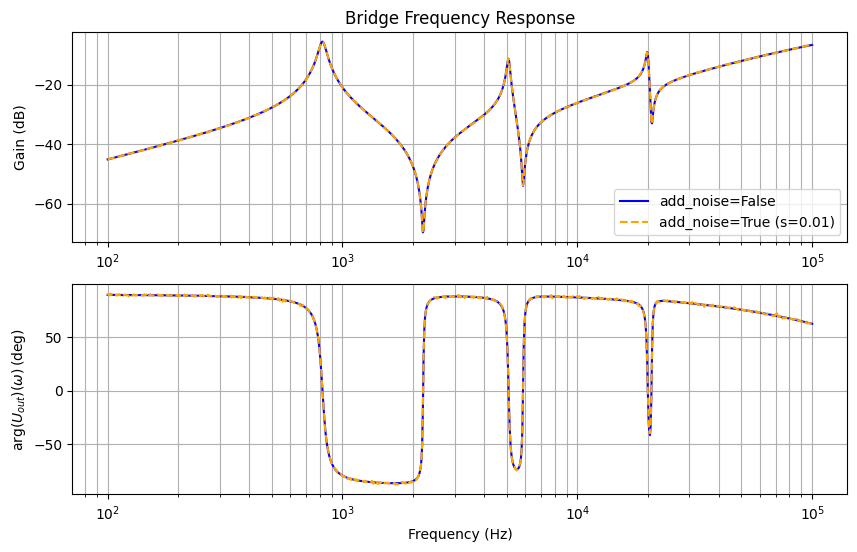

In [15]:
# A triangle with A in the floor, B inclined at the left and a C at the right:
topology = [(0, 2), (0, 1), (1, 2)]
struc = Bridge()
struc.construct(lib, topology)

# Solve for bridge frequency response, but let the solver add noise to U_out:

# Initialize RNG:
rng = np.random.default_rng(seed=42)
sigma = 0.01

# Run simulation with and without noise:
U_out = struc.solve_U(w_arr, U_in, R_ref, add_noise = False)
U_mag = np.abs(U_out)
U_phase = np.angle(U_out)

U_out_noise = struc.solve_U(w_arr, U_in, R_ref, add_noise = True, sigma=sigma, rng=rng)
U_mag_noise = np.abs(U_out_noise)
U_phase_noise = np.angle(U_out_noise)

# Plotting:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, 20*np.log10(U_mag/U_in), color='blue', label = 'add_noise=False')
plt.semilogx(f_arr, 20*np.log10(U_mag_noise/U_in), color='orange', linestyle='--', label = f'add_noise=True (s={sigma})')
plt.ylabel('Gain (dB)')
plt.grid(True, which="both")
plt.legend(loc = 'lower right')
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_phase), color='blue', label = 'add_noise=False')
plt.semilogx(f_arr, np.degrees(U_phase_noise), color='orange', linestyle='--', label = f'add_noise=True (s={sigma})')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

A good first look: in contrary to the notch filter, more distinct behaviour is visible in the plot. Now the moment of truth has arrived: how does the solver perform on deformed configurations?

R-values found, generating plot...
[5008.04912743 5283.74614904 4745.63383509]


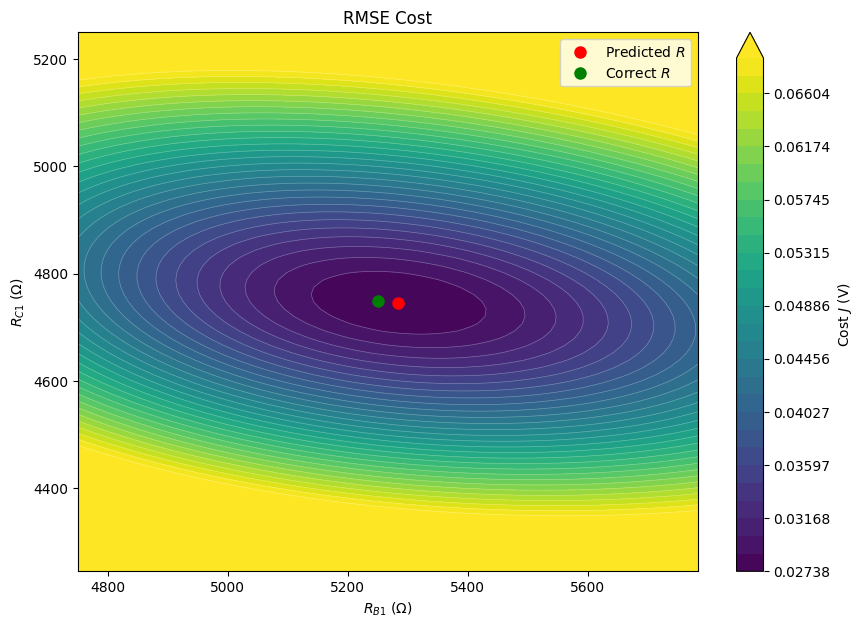

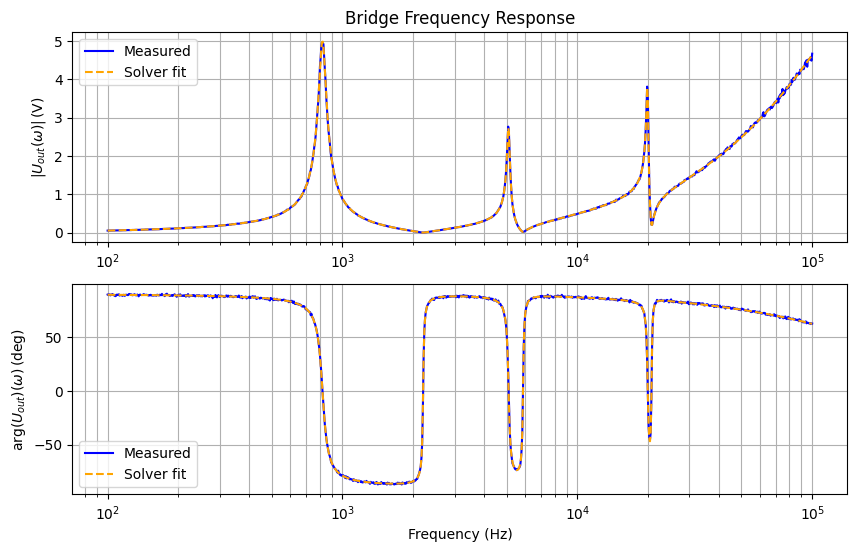

In [16]:
# Recover R values for deformed triangle WITHOUT noise:

# Let's pretend no deformation in A, but elongation in both B and C:
R_deformed = [5000.0, 5250.0, 4750.0]

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(U_in, R_ref, R_def=R_deformed, add_noise=True, sigma=sigma, rng=rng, error_plot=True, R_var=[1,2])
print(R_pred)

# Plotting:
U_out_mes = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_deformed, add_noise = True, sigma=sigma, rng=rng)
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_out_pred = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_pred, add_noise = False)
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()

A decent result, even if we switch the three beams around. For sigma=0.01, deviations do not exceed 50 Ohm (w.r.t. a standard resistance of 5000 Ohm, aka 1%). Now, we must try more difficult structures. Let's try the five beam construction.

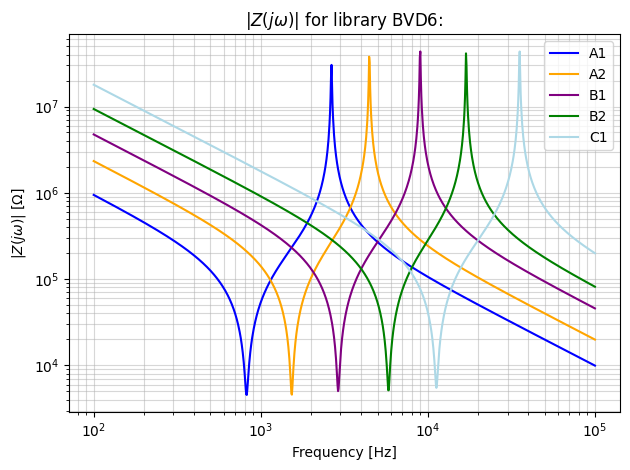

In [17]:
selection = ['A1', 'A2', 'B1', 'B2', 'C1']
lib = sublibrary(selection, library)

fig, ax = plt.subplots()
colors = ['blue', 'orange', 'purple', 'green', 'lightblue']

for beam, color in zip(list(lib.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()

[4500.00000001 4500.         4999.99999998 5000.         5500.        ]


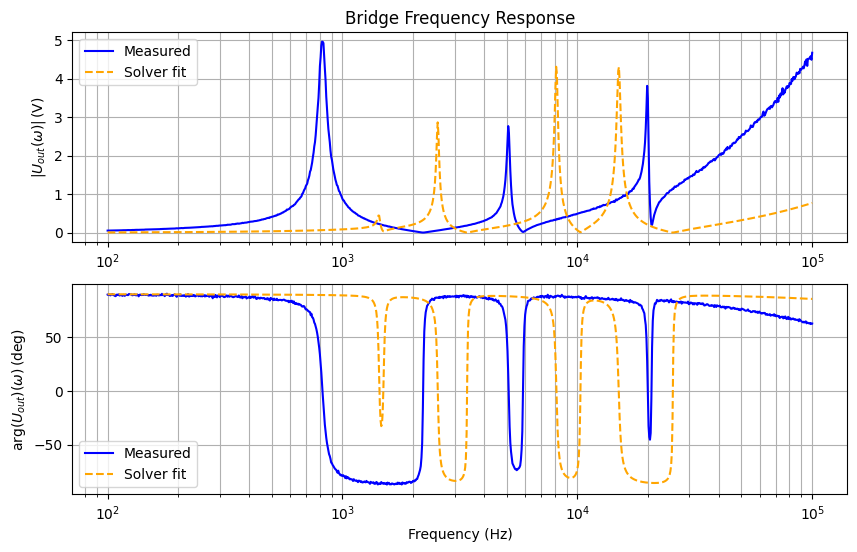

In [18]:
# A simple bridge structure:
#    2
# 0  1  3
topology = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
struc = Bridge()
struc.construct(lib, topology)

# Recover R values for deformed bridge:
# Let's pretend a force acting on the top node, pointed to the right.
R_deformed = [5250.0, 5500.0, 5250.0, 4750.0, 4500.0]

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(U_in, R_ref, add_noise=False, sigma=sigma, rng=rng)
print(R_pred)

# Plotting:
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_out_pred = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_pred)
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()



A few intresting observations were made. First of all, this simulation appears to be the first real example of where beam resonance interference (res. frequency too close together) causes problems. For `selection = ['A1','A2','B1','B2','C1']`, the simulation switches the resistances of B1 and B2: the same beam type. By applying `selection = ['A1','B1','A2','B2','C1']` (e.g.), this problem seems disappears.

One quick improvement:
- Check information density for improved cost function:
    1) First, check if this actually helps. I imagine changing R mainly effects the bumps, not the straight lines.
    2) If this appears to be true, create a resonance mask using solve_U for the given configuration and apply it to the cost function. Since we currently use the RMSE, taking the mean of an error that is almost zero for 90% of the frequencies can surpress the correlation between J and the R vector.

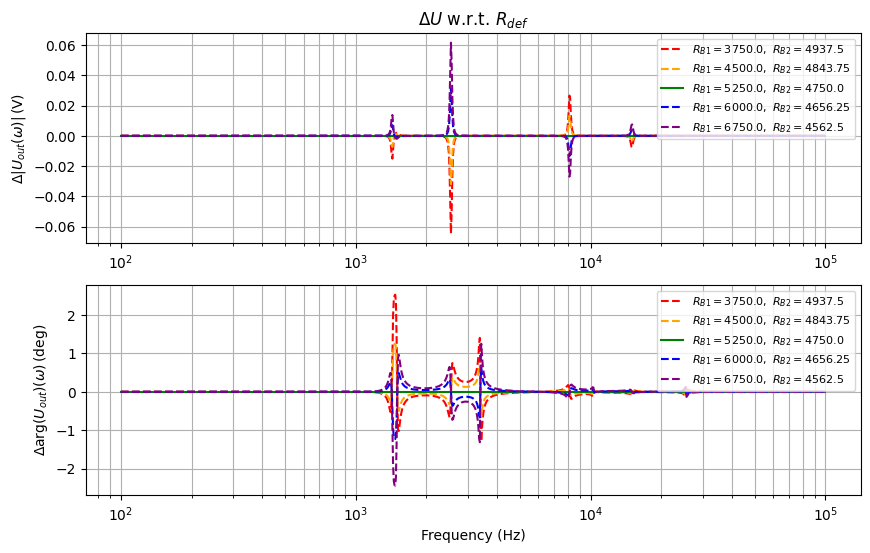

In [19]:
# Let us create an R-space that walks along the line R_B1 + 8*R_B2 = 43250, since this line approximately represents the cavity for
# the bridge above with- and without noise.

R_B1 = np.linspace(5250.0 - 1500.0, 5250.0 + 1500.0, 5) # Ohm
R_B2 = (43250 - R_B1)/8

R_space = np.full((len(R_deformed), len(R_B1)), R_deformed)
R_space[:,2] = R_B1
R_space[:,3] = R_B2

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
colors = ['r', 'orange', 'g', 'b', 'purple']
linestyles = ['--', '--', '-', '--', '--']

U_out_base = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_deformed)
U_mag_base = np.abs(U_out_base)
U_deg_base = np.degrees(np.angle(U_out_base))

for i, (color, linestyle) in enumerate(zip(colors, linestyles)):
    U_out_i = struc.solve_U(w_arr, U_in, R_ref, R_vec=R_space[i,:])
    dU_mag_i = U_mag_base - np.abs(U_out_i)
    dU_deg_i = U_deg_base - np.degrees(np.angle(U_out_i))

    ax[0].semilogx(f_arr, dU_mag_i, color=color, linestyle=linestyle, label = rf'$R_{{B1}} = {R_space[i, 2]},\ R_{{B2}} = {R_space[i, 3]}$')
    ax[1].semilogx(f_arr, dU_deg_i, color=color, linestyle=linestyle, label = rf'$R_{{B1}} = {R_space[i, 2]},\ R_{{B2}} = {R_space[i, 3]}$')


ax[0].set_ylabel(r'$\Delta|U_{out}(\omega)|\,(\text{V})$')
ax[0].grid(True, which="both")
ax[0].legend(fontsize=8, loc='upper right')
ax[0].set_title(r'$\Delta U\ \text{w.r.t.}\ R_{def}$')

ax[1].set_ylabel(r'$\Delta\text{arg}(U_{out})(\omega)\,(\text{deg})$')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].grid(True, which="both", ls="-")
ax[1].legend(fontsize=8, loc='upper right')

The following observation was made: high information density can be found, where the phase of U_out dives or rises through zero. For now, the hypothesis is made that changing other R's would result in peaks at these same positions too.

Still, one should be careful for the effect of coupling: changing the R values seems to change all peaks at once, instead of only effecting one peak. Another hypothesis is that beam resistance values effect their own resonance peak the most, which couples each beam to their resonance frequency. We can research this by plotting the partial derivatives: